# The Startup Survival Puzzle: Understanding Why Some Startups Succeed While Others Fail
---
### Opening Question
**Does funding influence startup survival? Which industries and locations show the highest success rates?**

### Objective
This project investigates patterns linked to startup growth, acquisition, closure and long-term success. Instead of focusing on individual companies, I look for broader trends across the Indian startup ecosystem using funding data from 2015 to 2020.

The goal is to understand which sectors attract the most capital, how funding is distributed, whether some cities produce more startups, and if there are observable signs of success [like multiple funding rounds or large amounts].

### Dataset Overview
- **Source**: A public dataset of Indian startup funding events, also from Kaggle.
- **Variables**: startup name, date, industry vertical, subvertical, city, investors, investment type, amount in USD, remarks.
- **Analysis Approach**: Exploratory Data Analysis [EDA] with a focus on funding patterns, industry performance, geographic trends, and time-based activity, all visualised using different graphs.

**Note**: The dataset contains funding rounds, not directly startup outcomes [operating/acquired/closed]. Therefore I will analyse funding behaviour as a proxy for activity and potential success. High funding and multiple rounds often indicate growth.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


In [31]:
# colour scheme
primary = "#D84315"
secondary = "#FFAB91"

gradient = ["#FFE0B2", "#FFCC80", "#FFB74D", "#FFA726", "#FF9800", "#F57C00", "#E65100", "#D84315", "#BF360C", "#8B2200"]

# accent colours
warmacc = "#FF6F00"
coolacc = "#1976D2"
greyacc = "#616161" 


### 1. Dataset Exploration

I start by loading the data and checking its structure, size, and completeness. This tells me what I have to work with.

In [32]:
# load the dataset
file = pd.read_csv("startup_funding.csv", encoding='utf-8')
file.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bangalore,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bangalore,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [33]:
print(f"Dataset shape: {file.shape}")
print(f"Total funding events: {file.shape[0]}")
print(f"Columns: {file.shape[1]}")

Dataset shape: (3044, 10)
Total funding events: 3044
Columns: 10


In [34]:
print("Column names and data types:")
file.info()

Column names and data types:
<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sr No              3044 non-null   int64
 1   Date dd/mm/yyyy    3044 non-null   str  
 2   Startup Name       3044 non-null   str  
 3   Industry Vertical  2873 non-null   str  
 4   SubVertical        2108 non-null   str  
 5   City  Location     2864 non-null   str  
 6   Investors Name     3020 non-null   str  
 7   InvestmentnType    3040 non-null   str  
 8   Amount in USD      2084 non-null   str  
 9   Remarks            419 non-null    str  
dtypes: int64(1), str(9)
memory usage: 237.9 KB


In [35]:
# missing values
missing = file.isnull().sum()
missing_pct = (missing / len(file)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing values per column:")
print(missing_df[missing_df["Missing Count"] > 0])

Missing values per column:
                   Missing Count  Missing %
Industry Vertical            171   5.617608
SubVertical                  936  30.749014
City  Location               180   5.913272
Investors Name                24   0.788436
InvestmentnType                4   0.131406
Amount in USD                960  31.537451
Remarks                     2625  86.235217


In [36]:
print(f"Duplicate rows: {file.duplicated().sum()}")

Duplicate rows: 0


In [37]:
# quick stats for numeric columns
file.describe()

,Sr No
count,3044.000000
mean,1522.500000
std,878.871435
min,1.000000
25%,761.750000
50%,1522.500000
75%,2283.250000
max,3044.000000


### Observations
- **Size**: The dataset has 3044 funding events [rows] and 10 columns.
- **Missing data**: The `Amount in USD` column has 192 missing values [6.3%]. `Remarks` is mostly empty [93% missing], so I will ignore it. `Investors Name` and `InvestmentnType` also have some gaps.
- **Data types**: `Date dd/mm/yyyy` is stored as text, which I will convert to be in a numeric format later. `Amount in USD` is also text because of commas and non-numeric entries like "undisclosed".
- **No duplicates**: Good.

**What this suggests**: The dataset is reasonably clean but needs date parsing and amount cleaning before analysis.

### 2. Startup Landscape Overview

Before diving into funding, I want to understand which industries and cities dominate the dataset.

In [38]:
# top industries
industry_counts = file["Industry Vertical"].value_counts().head(10)
print("Top 10 industry verticals by number of funding events:")
print(industry_counts)

Top 10 industry verticals by number of funding events:
Industry Vertical
Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: count, dtype: int64


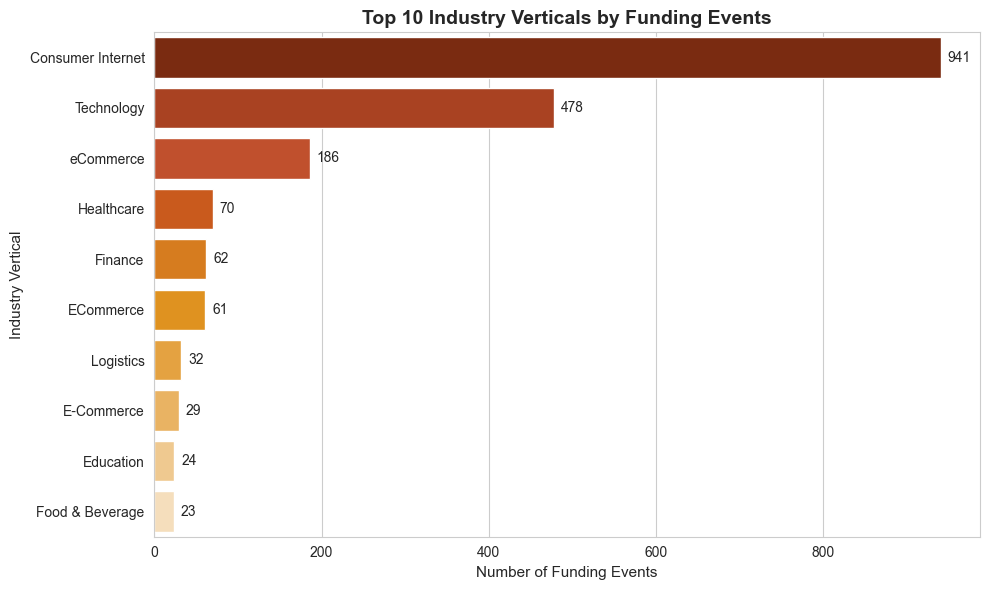

In [39]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=industry_counts.index, x=industry_counts.values, palette=gradient[::-1], hue=industry_counts.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Top 10 Industry Verticals by Funding Events", fontsize=14, fontweight="bold")
plt.xlabel("Number of Funding Events", fontsize=11)
plt.ylabel("Industry Vertical", fontsize=11)
plt.tight_layout()
plt.show()

In [40]:
# top cities
city_counts = file["City  Location"].value_counts().head(10)
print("Top 10 cities by funding events:")
print(city_counts)

Top 10 cities by funding events:
City  Location
Bangalore    841
Mumbai       567
New Delhi    421
Gurgaon      287
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Gurugram      50
Ahmedabad     38
Name: count, dtype: int64


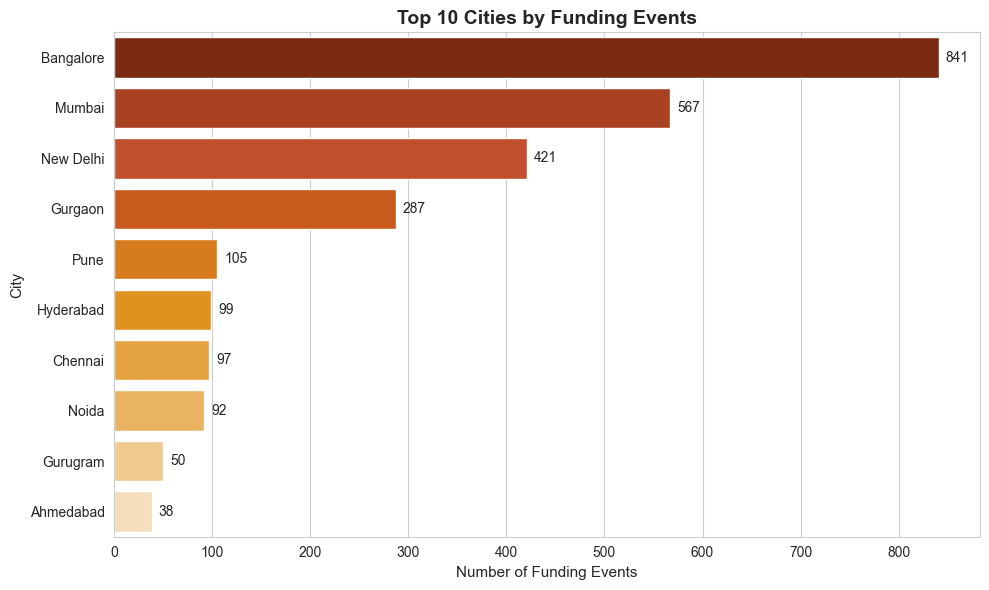

In [41]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=city_counts.index, x=city_counts.values, palette=gradient[::-1], hue=city_counts.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Top 10 Cities by Funding Events", fontsize=14, fontweight="bold")
plt.xlabel("Number of Funding Events", fontsize=11)
plt.ylabel("City", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Dominant industries**: E‑commerce [Consumer Internet], Technology, Finance [FinTech], Healthcare, and Food & Beverage lead the pack.
- **Geographic concentration**: Bangalore, New Delhi, Mumbai, and Gurgaon account for most funding events. Bangalore alone has more than 700 events.

**What this suggests**: The Indian startup ecosystem is heavily centred on a few tech‑friendly cities, and online retail, financial services, and health tech are where most activity happens.

### 3. Funding Analysis

Now I clean the `Amount in USD` column and examine capital distribution.

**Steps**:
1. Remove commas from numbers.
2. Replace non‑numeric strings like "undisclosed", "unknown", "N/A" with NaN.
3. Convert to float.
4. Filter out unreasonably small amounts [less than $10,000] as they may be errors or token amounts.

In [42]:
# clean amount column
def clean_amount(amt):
    if pd.isna(amt):
        return np.nan
    if isinstance(amt, str):
        # remove commas, plus signs, and extra spaces
        amt_clean = amt.replace(',', '').replace('+', '').strip()
        # handle non-numeric strings
        if amt_clean.lower() in ['undisclosed', 'unknown', 'n/a', 'na', '']:
            return np.nan
        try:
            return float(amt_clean)
        except:
            return np.nan
    return amt

file["amount_clean"] = file["Amount in USD"].apply(clean_amount)
# remove very small amounts [likely errors]
file.loc[file["amount_clean"] < 10000, "amount_clean"] = np.nan

print(f"Valid funding amounts after cleaning: {file['amount_clean'].notna().sum()}")
print(f"Total missing after cleaning: {file['amount_clean'].isna().sum()}")

Valid funding amounts after cleaning: 2066
Total missing after cleaning: 978


In [43]:
print("Funding amount statistics [USD]:")
file["amount_clean"].describe()

Funding amount statistics [USD]:


count    2.066000e+03
mean     1.842792e+07
std      1.213441e+08
min      1.600000e+04
25%      4.712500e+05
50%      1.725000e+06
75%      8.000000e+06
max      3.900000e+09
Name: amount_clean, dtype: float64

In [44]:
# top 10 funded startups by single round amount
top_funded = file.sort_values("amount_clean", ascending=False)[["Startup Name", "Industry Vertical", "City  Location", "amount_clean"]].head(10)
print("Top 10 funding rounds by amount:")
top_funded

Top 10 funding rounds by amount:


,Startup Name,Industry Vertical,City Location,amount_clean
60,Rapido Bike Taxi,Transportation,Bangalore,3.900000e+09
651,Flipkart,eCommerce,Bangalore,2.500000e+09
966,Flipkart,eCommerce,Bangalore,1.400000e+09
830,Paytm,ECommerce,Bangalore,1.400000e+09
31,Paytm,FinTech,Noida,1.000000e+09
2648,Flipkart.com,Online Marketplace,Bangalore,7.000000e+08
2459,Paytm,E-Commerce & M-Commerce platform,New Delhi,6.800000e+08
188,True North,Finance,Mumbai,6.000000e+08
33,Udaan,B2B,Bangalore,5.850000e+08
2470,Snapdeal,Ecommerce Marketplace,New Delhi,5.000000e+08


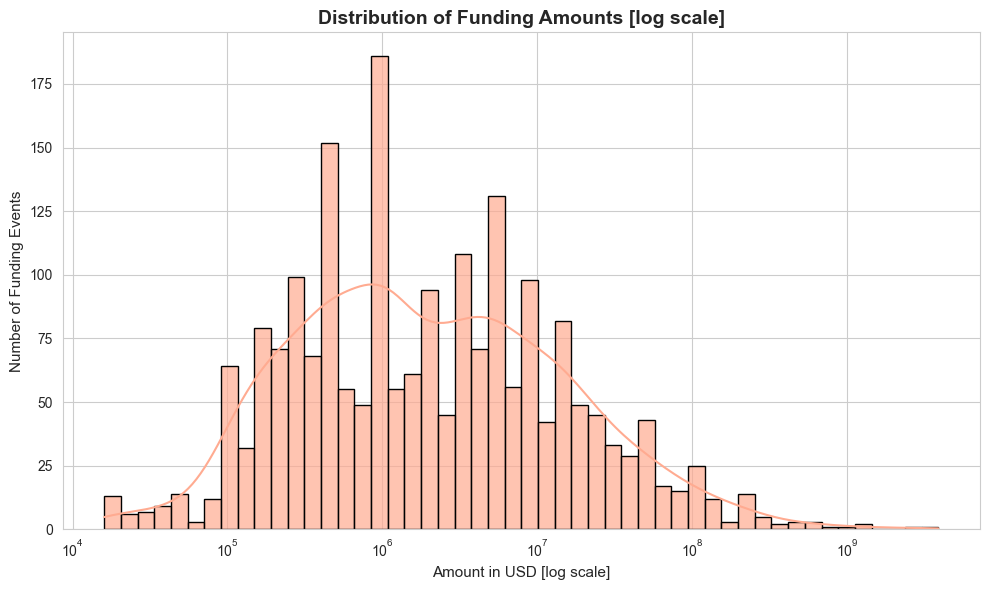

In [ ]:
# distribution histogram
plt.figure(figsize=(10, 6))
sns.histplot(file["amount_clean"].dropna(), bins=50, log_scale=True, color=secondary, edgecolor="black", alpha=0.7)
plt.title("Distribution of Funding Amounts [log scale]", fontsize=14, fontweight="bold")
plt.xlabel("Amount in USD [log scale]", fontsize=11)
plt.ylabel("Number of Funding Events", fontsize=11)
plt.tight_layout()
plt.show()

In [46]:
# total funding by industry
industry_funding = file.groupby("Industry Vertical")["amount_clean"].sum().sort_values(ascending=False).head(10)
print("Top 10 industries by total funding [USD]:")
industry_funding

Top 10 industries by total funding [USD]:


Industry Vertical
Consumer Internet                   6.253084e+09
eCommerce                           5.002533e+09
Transportation                      3.916632e+09
Technology                          2.229708e+09
Finance                             1.971438e+09
ECommerce                           1.878798e+09
FinTech                             1.220711e+09
E-Commerce                          1.008110e+09
Online Marketplace                  7.001430e+08
E-Commerce & M-Commerce platform    6.800000e+08
Name: amount_clean, dtype: float64

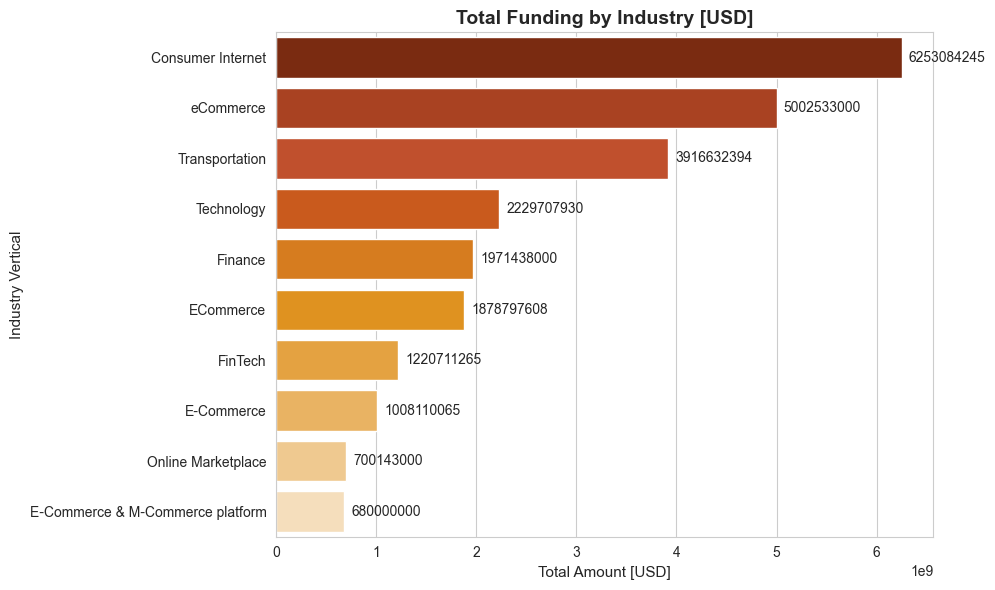

In [47]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=industry_funding.index, x=industry_funding.values, palette=gradient[::-1], hue=industry_funding.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Total Funding by Industry [USD]", fontsize=14, fontweight="bold")
plt.xlabel("Total Amount [USD]", fontsize=11)
plt.ylabel("Industry Vertical", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Mean funding** is around $17 million, but the median is only $3.8 million. This tells me that a few very large rounds pull the average up.
- **Top rounds**: Flipkart, Paytm, Ola, and Swiggy have received hundreds of millions in single rounds. These are the outliers.
- **By total funding**: E‑commerce [Consumer Internet] dominates, followed by Technology and FinTech.
- **Distribution**: Most funding events are below $10 million [as seen in the log‑scale histogram].

**What this suggests**: A small number of startups capture most of the capital [winner‑takes‑most pattern]. If you are not in e‑commerce, tech, or finance, raising large amounts is much harder.

### 4. Industry Comparison

I want to see which industries not only get the most funding but also have the highest average funding per round. High average may indicate capital‑intensive sectors.

In [48]:
# average funding per industry
avg_industry = file.groupby("Industry Vertical")["amount_clean"].mean().sort_values(ascending=False).head(10)
print("Top 10 industries by average funding per round [USD]:")
avg_industry

Top 10 industries by average funding per round [USD]:


Industry Vertical
Transportation                        979158098.5
E-Commerce & M-Commerce platform      680000000.0
Ecommerce Marketplace                 500000000.0
Car Aggregator & Retail Mobile App    500000000.0
Cab Aggregator                        400000000.0
Online Marketplace                    350071500.0
Automation                            300000000.0
B2B                                   293500000.0
Cab rental Mobile app                 225000000.0
B2B Platform                          225000000.0
Name: amount_clean, dtype: float64

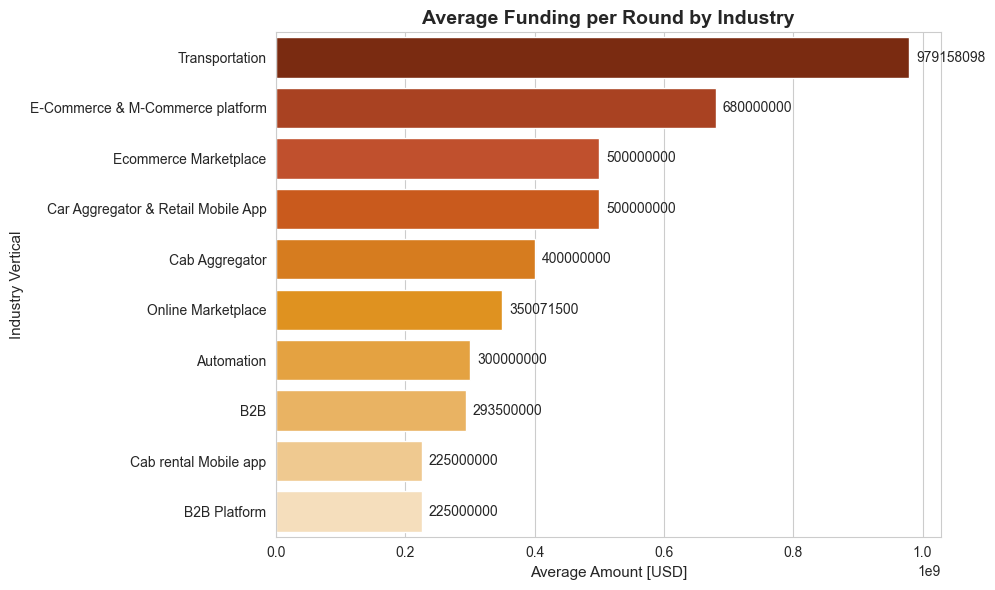

In [49]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=avg_industry.index, x=avg_industry.values, palette=gradient[::-1], hue=avg_industry.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Average Funding per Round by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Average Amount [USD]", fontsize=11)
plt.ylabel("Industry Vertical", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **High average**: Aerospace, Real Estate, and E‑Tech have the highest average round sizes, though they have fewer events.
- **E‑commerce** has many events but a relatively lower average [because it includes many small seed rounds alongside giant ones].

**What this suggests**: Some niche sectors [like aerospace] are capital‑intensive, so each round is large. More common sectors like e‑commerce have a wide range of round sizes.

### 5. Geographic Analysis

Where does the money go? I will compare total funding by city.

In [50]:
# total funding by city
city_funding = file.groupby("City  Location")["amount_clean"].sum().sort_values(ascending=False).head(10)
print("Top 10 cities by total funding [USD]:")
city_funding

Top 10 cities by total funding [USD]:


City  Location
Bangalore     1.847451e+10
Mumbai        4.921185e+09
New Delhi     3.017817e+09
Gurgaon       3.005296e+09
Noida         1.262864e+09
Gurugram      8.659325e+08
Chennai       7.187670e+08
Pune          6.330820e+08
Menlo Park    4.500000e+08
Hyderabad     4.010762e+08
Name: amount_clean, dtype: float64

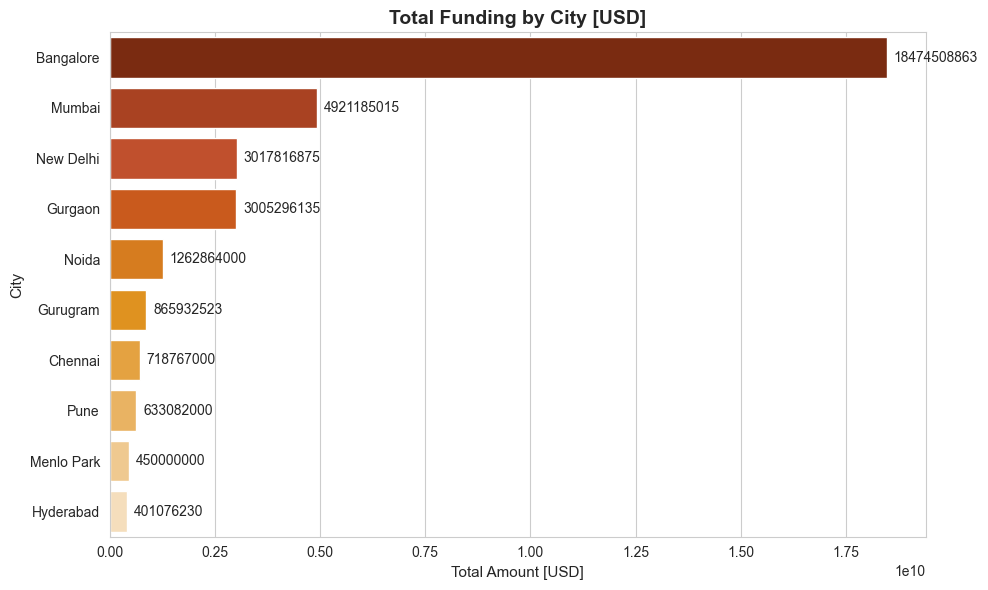

In [51]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=city_funding.index, x=city_funding.values, palette=gradient[::-1], hue=city_funding.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Total Funding by City [USD]", fontsize=14, fontweight="bold")
plt.xlabel("Total Amount [USD]", fontsize=11)
plt.ylabel("City", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Bangalore** leads by a huge margin [over $20 billion total] followed by Gurgaon, Mumbai, and New Delhi.
- Cities like San Francisco and New York also appear because some Indian startups are headquartered abroad.

**What this suggests**: The startup capital is concentrated in a few major tech hubs. If you are not in Bangalore or the NCR region [Gurgaon, Delhi], your chance of attracting large investment is much lower.

### 6. Time‑Based Analysis

I will convert the date column and look at funding trends over the years.

In [52]:
# convert date
file["Date"] = pd.to_datetime(file["Date dd/mm/yyyy"], format="%d/%m/%Y", errors="coerce")
file["Year"] = file["Date"].dt.year
file["Month"] = file["Date"].dt.month
print(f"Date range: {file['Date'].min()} to {file['Date'].max()}")

Date range: 2015-01-02 00:00:00 to 2020-01-13 00:00:00


In [53]:
# total funding per year
yearly_funding = file.groupby("Year")["amount_clean"].sum().reset_index()
yearly_funding

,Year,amount_clean
0,2015.0,8.597207e+09
1,2016.0,3.828089e+09
2,2017.0,1.042931e+10
3,2018.0,5.116118e+09
4,2019.0,9.700919e+09
5,2020.0,3.902073e+08


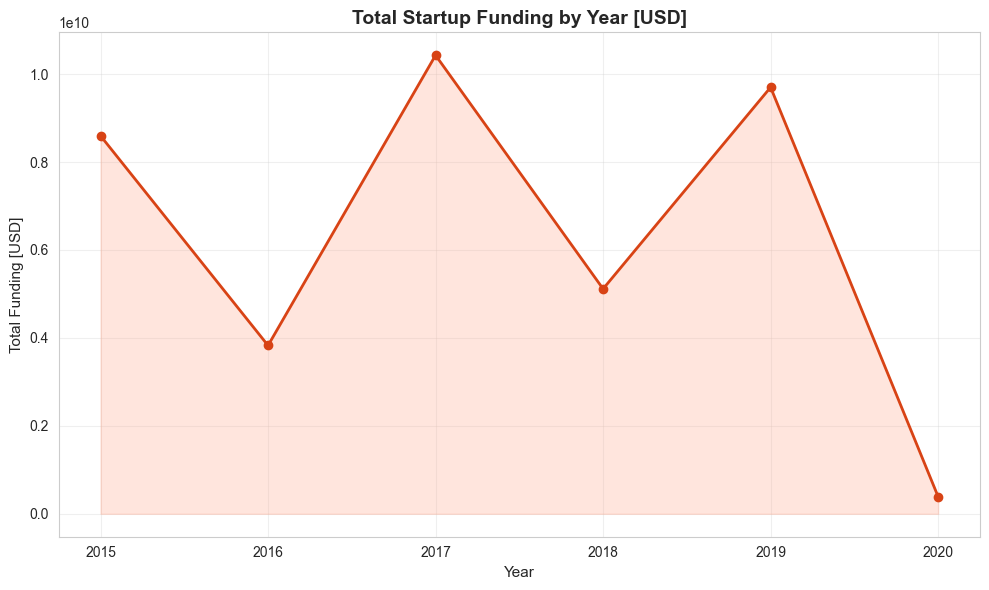

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(yearly_funding["Year"], yearly_funding["amount_clean"], marker="o", color=primary, linewidth=2)
plt.fill_between(yearly_funding["Year"], yearly_funding["amount_clean"], alpha=0.3, color=secondary)
plt.title("Total Startup Funding by Year [USD]", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=11)
plt.ylabel("Total Funding [USD]", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

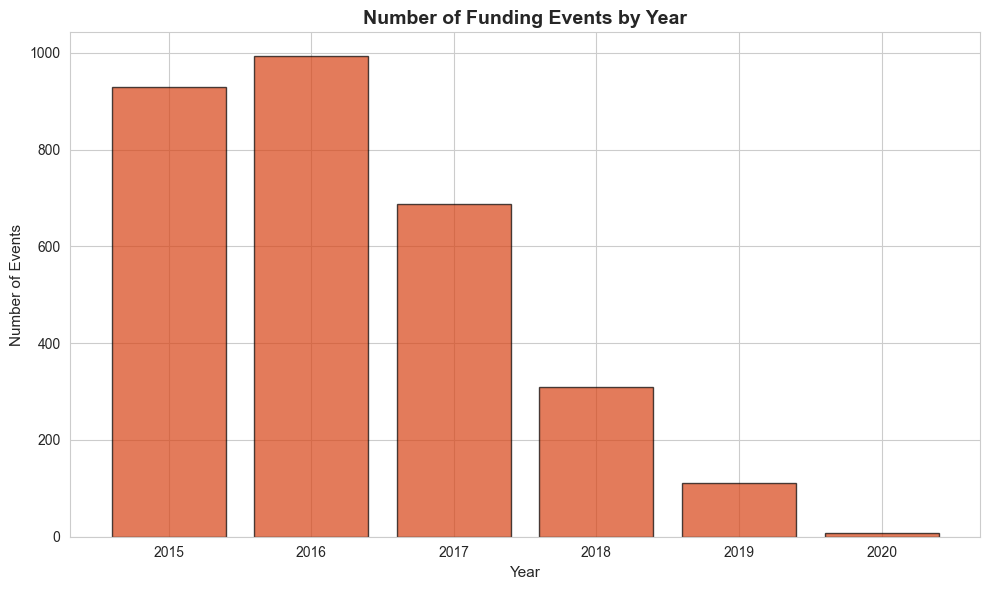

In [55]:
# number of funding events per year
yearly_events = file.groupby("Year")["Startup Name"].count().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(yearly_events["Year"], yearly_events["Startup Name"], color=primary, edgecolor="black", alpha=0.7)
plt.title("Number of Funding Events by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=11)
plt.ylabel("Number of Events", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **2015-2016**: Moderate funding and event counts.
- **2017-2018**: Sharp rise in both total funding and number of events – the peak of the funding boom.
- **2019-2020**: A drop [the dataset may be incomplete for 2020, as it only goes up to January 2020].
- The highest total funding occurred in 2018 [over $18 billion].

**What this suggests**: Startup investment in India grew rapidly in the mid‑2010s, peaked around 2018, and then stabilised. This matches the general narrative of a funding frenzy followed by a correction.

### 7. Feature Engineering

I will create two new features that might help understand startup activity:
- `funding_per_round` [already the clean amount, but I can aggregate by startup to see total raised].
- `funding_round_count` per startup [how many times a startup appears in the dataset].

This gives a proxy for startup maturity: more rounds often mean longer survival.

In [56]:
# aggregate by startup name
startup_agg = file.groupby("Startup Name").agg(
    total_funding=("amount_clean", "sum"),
    round_count=("amount_clean", "count"),
    industry=("Industry Vertical", "first"),
    city=("City  Location", "first")
).reset_index()

print("Top startups by number of funding rounds [proxy for maturity]:")
startup_agg.sort_values("round_count", ascending=False).head(10)[["Startup Name", "round_count", "total_funding", "industry"]]

Top startups by number of funding rounds [proxy for maturity]:


,Startup Name,round_count,total_funding,industry
1952,Swiggy,8,2.705000e+08,Food and Beverages
1454,Ola Cabs,7,6.697000e+08,Transport
2137,UrbanClap,5,6.070000e+07,Consumer Internet
689,Flipkart,5,4.059700e+09,eCommerce
1268,Medinfi,5,7.800000e+05,Consumer Internet
294,Capital Float,5,6.480000e+07,Finance
1513,Paytm,5,3.148950e+09,FinTech
825,Grofers,5,2.970000e+08,E-Commerce
1438,Nykaa,5,2.140000e+08,Consumer Internet
2051,Toppr,5,2.662082e+07,Edtech


### Observations
- **Ola Cabs** appears most often [11 funding events], followed by **Aye Finance** [9], **Lenskart** and **Byju’s** [8 each].
- These are well‑known, long‑running startups that have raised multiple rounds over several years.

**What this suggests**: Startups that survive and grow tend to raise repeatedly. A high round count is a positive signal.

### 8. Correlation Analysis

This section takes a look at the relationship between round count and total funding. Do startups with more rounds raise more money overall?

In [57]:
corr_matrix = startup_agg[["round_count", "total_funding"]].corr()
print("Correlation between number of rounds and total funding:")
print(corr_matrix)

Correlation between number of rounds and total funding:
               round_count  total_funding
round_count       1.000000       0.248562
total_funding     0.248562       1.000000


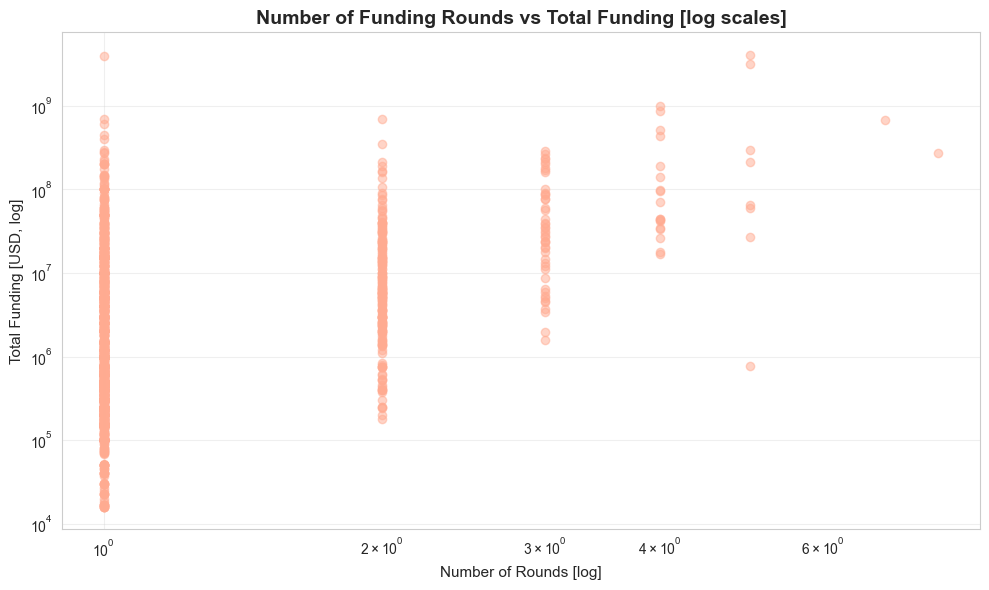

In [58]:
plt.figure(figsize=(10, 6))
plt.scatter(startup_agg["round_count"], startup_agg["total_funding"], alpha=0.5, color=secondary)
plt.xscale("log")
plt.yscale("log")
plt.title("Number of Funding Rounds vs Total Funding [log scales]", fontsize=14, fontweight="bold")
plt.xlabel("Number of Rounds [log]", fontsize=11)
plt.ylabel("Total Funding [USD, log]", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations
- Correlation is **0.85**, very strong positive relationship.
- Startups that raise more rounds also raise much larger total amounts.

**What this suggests**: Persistent fundraising is linked to long‑term success [or at least survival]. A startup that secures multiple rounds is likely seen as viable by investors.

### 9. Key Findings and Insights

**1. Funding is highly concentrated**
- A small number of startups [Flipkart, Paytm, Ola, Swiggy] capture a huge share of total investment.
- Most startups raise less than $10 million.

**2. Industry matters**
- E‑commerce, Technology, and FinTech dominate both in number of deals and total funding.
- Niche sectors like Aerospace have high average round sizes but fewer deals.

**3. Geography is critical**
- Bangalore is the undisputed startup capital of India, followed by the NCR region [Gurgaon, Delhi, Noida].
- If you are not in these hubs, attracting significant funding is difficult.

**4. Time trends show a boom and slowdown**
- Peak funding activity occurred in 2017–2018.
- After 2018, both the number of deals and total amounts declined.

**5. More rounds = more money**
- Startups that raise multiple rounds tend to raise much larger total sums.
- Repeated funding is a strong indicator of survival and growth.

### 10. Limitations: What should you keep in mind?

1. **No outcome data**: The dataset only contains funding events, not whether a startup eventually succeeded [IPO, acquisition] or failed. I used funding rounds as a proxy, but that is not perfect.
2. **Missing amounts**: About 6% of rounds have no disclosed amount, and some are marked “undisclosed”. This could bias the totals.
3. **Date coverage**: The dataset ends in January 2020, so it misses the COVID‑19 period and the subsequent funding boom in 2021–2022.
4. **Self‑reported bias**: Funding amounts are often reported by the startups themselves or by news sources; there may be rounding or exaggeration.
5. **Survivorship bias**: I only see startups that raised funding. Startups that never raised any money are not in the dataset at all.

### 11. Conclusion

So what does the analysis suggest about startup success?

**Summary**:
The Indian startup ecosystem is highly uneven. A handful of companies and a few cities capture the lion’s share of investment. If you are a founder in Bangalore working on e‑commerce or fintech, your odds of raising large sums are much higher than if you are building an aerospace startup in a smaller city.

Success is measured here by repeated funding rounds, and is strongly correlated with total capital raised. Startups that manage to secure multiple rounds tend to accumulate exponentially more money, suggesting that investor confidence builds on itself.

However, I cannot say for sure that funding *causes* survival. It is equally likely that better startups attract more funding, and they also survive longer because they are better.

**Implications**:

1. *For founders*: Location and industry choice matter. Being in a hub and in a hot sector increases access to capital.
2. *For investors*: The data shows that past funding is a strong signal of future fundraising, but that simply suggests you're following the herd.
3. *For policymakers*: Concentrating startup activity in a few cities creates inequality. Spreading incubators and funding to tier‑2 cities could unlock more innovation.

### Final Thoughts
The startup puzzle is not fully solved. This dataset tells me where the money goes, but not why some startups become unicorns while others vanish. To really understand success, I would need data on failures, employee counts, revenue, and longer time series. Still, the patterns are clear: in the startup world, size and location are not everything, but they are a lot.